In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:

import os
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.98"

import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

plt.style.use("../../dmri/utils/pyloric.mplstyle")


ERROR:2026-01-18 15:11:35,687:jax._src.xla_bridge:477: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda13.initialize()
Traceback (most recent call last):
  File "/home/macke/mgloeckler90/miniconda3/envs/new_dmri2/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 475, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/macke/mgloeckler90/miniconda3/envs/new_dmri2/lib/python3.11/site-packages/jax_plugins/xla_cuda13/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/macke/mgloeckler90/miniconda3/envs/new_dmri2/lib/python3.11/site-packages/jax_plugins/xla_cuda13/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was una

In [3]:
mse_all = np.load("outputs/generalization_errors_all/all_mse.npz")
mse_b3s = np.load("outputs/generalization_errors_all/b3s_mse.npz")
mse_b3t = np.load("outputs/generalization_errors_all/b3t_mse.npz")
mse_csd = np.load("outputs/generalization_errors_all/csd_mse.npz")
mse_dti = np.load("outputs/generalization_errors_all/dti_mse.npz")
mse_rumba = np.load("outputs/generalization_errors_all/rumba_mse.npz")
print(list(mse_all.keys()))

['all_train_mse', 'all_loo_mse', 'all_train_mse_samples', 'all_loo_mse_samples']


In [4]:
mse_train_all =  mse_all["all_train_mse"]
mse_train_all = mse_train_all[~np.isnan(mse_train_all)]
mse_train_b3s =  mse_b3s["b3s_train_mse"]
mse_train_b3s = mse_train_b3s[~np.isnan(mse_train_b3s)]
mse_train_b3t =  mse_b3t["b3t_train_mse"]
mse_train_b3t = mse_train_b3t[~np.isnan(mse_train_b3t)]
mse_train_csd =  mse_csd["csd_train_mse"]
mse_train_csd = mse_train_csd[~np.isnan(mse_train_csd)]
mse_train_dti =  mse_dti["dti_train_mse"]
mse_train_dti = mse_train_dti[~np.isnan(mse_train_dti)]
mse_train_rumba =  mse_rumba["rumba_train_mse"]
mse_train_rumba = mse_train_rumba[~np.isnan(mse_train_rumba)]

In [28]:
mse_loocv_all =  mse_all["all_loo_mse"]
mse_loocv_all = mse_loocv_all[~np.isnan(mse_loocv_all)]
mse_loocv_b3s =  mse_b3s["b3s_loo_mse"]
mse_loocv_b3s = mse_loocv_b3s[~np.isnan(mse_loocv_b3s)]
mse_loocv_b3t =  mse_b3t["b3t_loo_mse"]
mse_loocv_b3t = mse_loocv_b3t[~np.isnan(mse_loocv_b3t)]
mse_loocv_csd =  mse_csd["csd_loo_mse"]
mse_loocv_csd = mse_loocv_csd[~np.isnan(mse_loocv_csd)]
mse_loocv_dti =  mse_dti["dti_loo_mse"]
mse_loocv_dti = mse_loocv_dti[~np.isnan(mse_loocv_dti)]
mse_loocv_rumba =  mse_rumba["rumba_loo_mse"]
mse_loocv_rumba = mse_loocv_rumba[~np.isnan(mse_loocv_rumba)]

In [69]:
def bootstrap_mean(errors, n_bootstrap=100,):
    # Vectorized bootstrap mean estimation
    errors = jnp.asarray(errors)
    n_samples = errors.shape[0]
    indices = jax.random.randint(jax.random.PRNGKey(0), (n_bootstrap, 50_000), 0, n_samples)
    bootstrapped_means = jnp.mean(errors[indices], axis=1)
    bootstrapped_rmse = jnp.sqrt(bootstrapped_means)

    return jnp.mean(bootstrapped_rmse), jnp.std(bootstrapped_rmse)

mean_all, std_all = bootstrap_mean(mse_train_all)
mean_b3s, std_b3s = bootstrap_mean(mse_train_b3s)
mean_b3t, std_b3t = bootstrap_mean(mse_train_b3t)
mean_csd, std_csd = bootstrap_mean(mse_train_csd)
mean_dti, std_dti = bootstrap_mean(mse_train_dti)
mean_rumba, std_rumba = bootstrap_mean(mse_train_rumba)

In [70]:
gen_mean_all, gen_std_all = bootstrap_mean(mse_loocv_all)
gen_mean_b3s, gen_std_b3s = bootstrap_mean(mse_loocv_b3s)
gen_mean_b3t, gen_std_b3t = bootstrap_mean(mse_loocv_b3t)
gen_mean_csd, gen_std_csd = bootstrap_mean(mse_loocv_csd)
gen_mean_dti, gen_std_dti = bootstrap_mean(mse_loocv_dti)
gen_mean_rumba, gen_std_rumba = bootstrap_mean(mse_loocv_rumba)

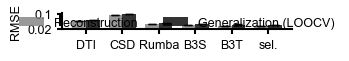

In [76]:
# Create a single plot with both training and generalization errors
fig, ax = plt.subplots(1, 1, figsize=(3.4, 0.9))

x = np.arange(6)*2
width = 0.75

# Training errors
train_bars = ax.bar(x - width/2, [mean_dti, mean_csd, mean_rumba, mean_b3s, mean_b3t, mean_all],
                   width, label='Reconstruction', yerr=[std_dti, std_csd, std_rumba, std_b3s, std_b3t, std_all],
                   color='grey', alpha=0.8, capsize=3)

# Generalization errors
gen_bars = ax.bar(x + width/2, [gen_mean_dti, gen_mean_csd, gen_mean_rumba, gen_mean_b3s, gen_mean_b3t, gen_mean_all],
                 width, label='Generalization (LOOCV)', yerr=[gen_std_dti, gen_std_csd, gen_std_rumba, gen_std_b3s, gen_std_b3t, gen_std_all],
                 color='k', alpha=0.8, capsize=3)

ax.set_ylabel('RMSE')
import matplotlib.ticker as mticker

ax.set_yscale('log')
#ax.set_ylim(0.02, 0.8)

# keep your major ticks/labels
ax.set_yticks([0.02, 0.1])
ax.set_yticklabels(['0.02', '0.1'])

# keep minor ticks, but remove minor labels
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.set_xticks(x)
ax.set_xticklabels(["DTI", "CSD", "Rumba", "B3S", "B3T", "sel."])
ax.legend(frameon=False, ncol=2, bbox_to_anchor=(0.5, 1.45), loc='upper center')
#ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.show()
fig.savefig("generalization_error.svg", dpi=300, bbox_inches='tight', transparent=True)


In [100]:
from dmri.train.utils import load_cfg, load_checkpoint

#checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/new_multishell_ball3stick_simformer6_v_pred")
checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/updated_all_3_6_8_128_model_prior")
graphdef, params,  state = nnx.split(model, nnx.Param,  ...)
params = checkpoint["params_ema"]

model = nnx.merge(graphdef, params, state)
sim_type = model.tokenizer.simulator
model.eval()

In [4]:
checkpoint, model_conv, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/updated_all_3_6_8_128_model_prior_with_convs_2gpus")
graphdef, params,  state = nnx.split(model_conv, nnx.Param,  ...)
params = checkpoint["params_ema"]

model_conv = nnx.merge(graphdef, params, state)
sim_type_conv = model_conv.tokenizer.simulator
model_conv.eval()

In [87]:
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti

import numpy as np

folder_name = "data"
data, affine = load_nifti(f"../../data/{folder_name}/data.nii.gz")
brain_mask, _ = load_nifti(f"../../data/{folder_name}/nodif_brain_mask.nii.gz")
_bvals, bvecs = read_bvals_bvecs(f"../../data/{folder_name}/bvals", f"../../data/{folder_name}/bvecs")

# Round bvals to nearest (0, 1000, 2000)
bvals_rounded = np.round(_bvals / 1000) * 1000
bvals = np.clip(bvals_rounded, 0, None)
b0_mask = bvals == 0

S0 = np.mean(data[..., b0_mask], -1)

data_norm = data / S0[..., None]
data_norm = np.where(brain_mask[...,None], data_norm, 0.)
data_norm = np.where(np.isnan(data_norm), 0., data_norm)
S0 = np.where(brain_mask, S0, 0.)


idx = np.argsort(bvals)

# Erode brain mask to exclude skull voxels
from scipy.ndimage import binary_erosion
brain_mask = binary_erosion(brain_mask, iterations=2)

bvals = bvals[idx]
bvecs = bvecs[idx]
data_norm = data_norm[...,idx]
#data_norm = data_norm[..., 36:37, :]
#brain_mask = brain_mask[..., 36:37]
data_norm = data_norm[..., 40:41, :]
brain_mask = brain_mask[..., 40:41]



full_data_flat = data_norm.reshape(-1, data_norm.shape[-1])
brain_mask_flat = brain_mask.reshape(-1)

full_data_flat_in_brain = full_data_flat[brain_mask_flat.astype(np.bool),:]
full_data_flat_in_brain = np.nan_to_num(full_data_flat_in_brain, nan=0, posinf=0, neginf=0)

exclude_outliers = np.quantile(full_data_flat_in_brain, 0.999)
full_data_flat_in_brain = np.clip(full_data_flat_in_brain, 0, exclude_outliers)

acq = acquisition_scheme(np.array(bvals), np.array(bvecs))


/tmp/ipykernel_3006769/182689284.py:19: RuntimeWarning: divide by zero encountered in divide
  data_norm = data / S0[..., None]
/tmp/ipykernel_3006769/182689284.py:19: RuntimeWarning: invalid value encountered in divide
  data_norm = data / S0[..., None]


In [88]:
import numpy as np
from dipy.reconst.rumba import RumbaSDModel
from dipy.core.gradients import gradient_table
from dipy.reconst.csdeconv import auto_response_ssst

# data: (X, Y, Z, N) diffusion data
# gtab: DIPY GradientTable
# mask: optional (X, Y, Z) boolean mask
gtab = gradient_table(bvals, bvecs)

response, _ = auto_response_ssst(gtab, data_norm, roi_radii=10, fa_thr=0.7)
print(response)

rumba = RumbaSDModel(gtab, voxelwise=True, wm_response=response[0])   # configure as needed
fit = rumba.fit(full_data_flat_in_brain)                        # or rumba.fit(data, mask=mask) depending on DIPY version

pred = fit.predict(gtab=gtab)                # (X, Y, Z, N)

resid = full_data_flat_in_brain - pred                          # (X, Y, Z, N)
# RMSE per voxel (scalar map):
rmse_map = np.mean(resid**2, axis=-1)

/tmp/ipykernel_3006769/3665074041.py:9: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  gtab = gradient_table(bvals, bvecs)


(array([0.00156445, 0.00030218, 0.00030218]), np.float32(1.0))


In [148]:
jnp.sqrt(rmse_map).mean()

Array(0.02935788, dtype=float32)

In [154]:
jnp.sqrt(errors_b3s_mean).mean()

Array(0.01908899, dtype=float32)

In [150]:
bootstrap_mean(rmse_map, n_bootstrap=10000)

(Array(0.0338858, dtype=float32), Array(0.0003752, dtype=float32))

In [8]:

from dipy.reconst.csdeconv import auto_response_ssst, ConstrainedSphericalDeconvModel,mask_for_response_ssst, response_from_mask_ssst

# data: (X, Y, Z, N) diffusion data
# gtab: DIPY GradientTable
# mask: optional (X, Y, Z) boolean mask
gtab = gradient_table(bvals, bvecs)

response, ratio = auto_response_ssst(gtab, data_norm, roi_radii=10, fa_thr=0.7)
mask = mask_for_response_ssst(gtab, data_norm, roi_radii=10, fa_thr=0.7)
nvoxels = np.sum(mask)
print(nvoxels)

response, ratio = response_from_mask_ssst(gtab, data_norm, mask)

csd_model = ConstrainedSphericalDeconvModel(gtab, response)   # configure as needed
fit = csd_model.fit(full_data_flat_in_brain)                        # or csd_model.fit(data, mask=mask) depending on DIPY version

pred = fit.predict(gtab=gtab)                # (X, Y, Z, N)

resid = data_norm - pred                          # (X, Y, Z, N)
# RMSE per voxel (scalar map):
rmse_csd = np.mean(resid**2, axis=-1)

/tmp/ipykernel_3006769/2917588509.py:6: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  gtab = gradient_table(bvals, bvecs)


39


In [9]:
from dipy.reconst.dti import TensorModel

ft = TensorModel(gtab).fit(full_data_flat_in_brain)
pred_tens = ft.predict(gtab)
resid_tens = full_data_flat_in_brain - pred_tens
rmse_tens = np.mean(resid_tens**2, axis=-1)

In [136]:
rmse_map.mean()

np.float64(0.0011482484059113353)

In [16]:
m_b3s = jnp.array([True, True, True, True] + [False]*6 + [True, False])
m_b3t = jnp.array([True] + [False]*6 + [True]*3 + [True, False])

In [169]:
import jax
import jax.numpy as jnp
from functools import partial

def _loo_indices(n: int, eval_index: jnp.ndarray) -> jnp.ndarray:
    """
    Returns indices of shape (n-1,) that select all entries except eval_index.
    JIT-safe: output shape is static (n-1).
    """
    base = jnp.arange(n - 1)
    # Shift indices >= eval_index up by 1 so we "skip" eval_index
    return base + (base >= eval_index).astype(base.dtype)

@partial(jax.jit, static_argnames=("model", "sim_type", "temperature", "temperature", "num_samples"))
def pred_error_loo(rng, acq, model_mask, x, lam=1.0, eval_index=None, model=model, sim_type=sim_type, temperature=1.0, num_samples=1):
    """
    JIT-compatible leave-one-out prediction error for a *single* eval_index.
    Shapes are static: train has (N-1, ...), eval has (1, ...).
    """
    x = jnp.asarray(x)
    acq = jax.tree_util.tree_map(jnp.asarray, acq)

    n_total = x.shape[0]
    if eval_index is not None:
        eval_index = jnp.asarray(eval_index, dtype=jnp.int32)
        idx_train = _loo_indices(n_total, eval_index)
        x_train = jnp.take(x, idx_train, axis=0)
        acq_train = jax.tree_util.tree_map(lambda a: jnp.take(a, idx_train, axis=0), acq)

        # Static-shape (keepdims=True makes leading dim == 1)
        x_eval = jax.lax.dynamic_index_in_dim(x, eval_index, axis=0, keepdims=True)
        acq_eval = jax.tree_util.tree_map(
            lambda a: jax.lax.dynamic_index_in_dim(a, eval_index, axis=0, keepdims=True),
            acq,
        )
    else:
        x_train = x
        acq_train = acq
        x_eval = x
        acq_eval = acq

    rng_theta, rng_signal = jax.random.split(rng)



    # Static-shape gathers


    if model_mask is None:
        rng_mask, rng_signal = jax.random.split(rng_signal)
        model_mask = model.sample_mask(rng_mask, acq_train, x_train, jnp.array([lam]), temperature=temperature)

    theta = model.sample_theta(rng_theta, acq_train, x_train, model_mask, temperature=temperature, num_steps=64)
    jax.tree_util.tree_map(lambda y: print(y.shape), acq_train)
    jax.tree_util.tree_map(lambda y: print(y.shape), x_train)
    sim = sim_type.from_theta(theta, model_mask=model_mask)
    signal_pred = sim.signal(acq_eval)  # expected shape (1, ...)
    err = jnp.nanmean((signal_pred - x_eval) ** 2, axis=-1)  # shape (1,) or (1, k)
    return jnp.squeeze(err)  # scalar (or remove squeeze if you want vector outputs)


def leave_one_out_error(rng, acq, model_mask, x, n_samples=100, offset=5, lam=1.0):
    """
    JIT-compatible aggregate LOO error over eval indices [offset, offset+n_samples).
    Uses lax.scan to avoid Python loops under jit.
    """
    x = jnp.asarray(x)
    n_total = x.shape[0]

    # Indices are static-length (n_samples,)
    eval_indices = jnp.arange(offset, offset + n_samples, dtype=jnp.int32)

    # Optional: keep indices in-bounds in a JIT-safe way (clipping does not change shape)
    eval_indices = jnp.clip(eval_indices, 0, n_total - 1)

    def body(idx):
        rng_i = jax.random.fold_in(rng, idx)
        return pred_error_loo(rng_i, acq, model_mask, x, lam=lam, eval_index=idx)

    errors = jax.lax.map(body, eval_indices, batch_size=10)
    return errors


# Recommended JIT wrappers (optional)
pred_error = pred_error_loo
leave_one_out_error_jit = jax.jit(leave_one_out_error)


In [170]:
def bootstrap_mean(errors, n_bootstrap=100):
    # Vectorized bootstrap mean estimation
    errors = jnp.asarray(errors)
    n_samples = errors.shape[0]
    indices = jax.random.randint(jax.random.PRNGKey(0), (n_bootstrap, n_samples), 0, n_samples)
    bootstrapped_means = jnp.mean(errors[indices], axis=1)
    bootstrapped_rmse = jnp.sqrt(bootstrapped_means)

    return jnp.mean(bootstrapped_rmse), jnp.std(bootstrapped_rmse)

In [171]:
from functools import partial

pred_error(jax.random.PRNGKey(0), acq, m_b3s, full_data_flat_in_brain[0],temperature=0.1)

(105,)
(105, 3)
(105,)


Array(0.00104206, dtype=float32)

In [78]:
bootstrap_mean(rmse_map)

(Array(0.04582961, dtype=float32), Array(0.00093563, dtype=float32))

In [184]:
errors_b3s = []
for i in range(10):
    keys = jax.random.split(jax.random.PRNGKey(i), full_data_flat_in_brain.shape[0])
    errors_b3s += [jax.vmap(partial(pred_error, temperature=0.2), in_axes=(0, None, None, 0))(keys, acq, m_b3s, full_data_flat_in_brain)]
errors_b3s = jnp.stack(errors_b3s)
errors_b3s_min = jnp.nanmin(errors_b3s, axis=0)
errors_b3s_mean = jnp.nanmean(errors_b3s, axis=0)

(105,)
(105, 3)
(105,)


In [186]:
jnp.nanmean(jnp.sqrt(errors_b3s_mean))

Array(0.02188508, dtype=float32)

In [187]:
jnp.nanmean(jnp.sqrt(errors_b3s_min))

Array(0.02119926, dtype=float32)

In [180]:
bootstrap_mean(errors_b3s[jnp.isnan(errors_b3s)==False], n_bootstrap=100)

(Array(0.02313887, dtype=float32), Array(0.00015175, dtype=float32))

In [182]:
jnp.isnan(errors_b3s).sum()

Array(34, dtype=int32)

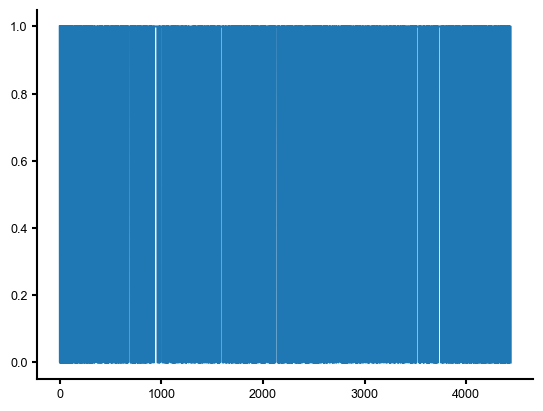

In [145]:
plt.plot(rmse_map > errors_b3s_min )

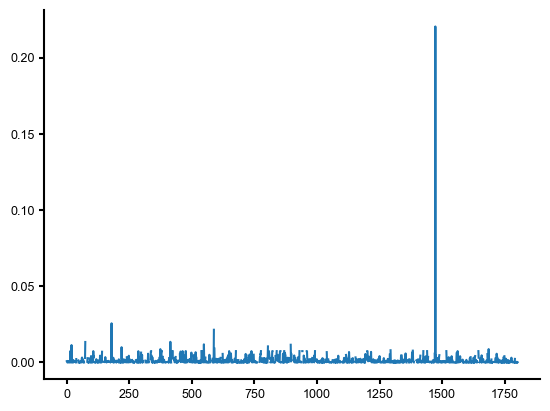

In [201]:
errors_b3t = []
for i in range(10):
    keys = jax.random.split(jax.random.PRNGKey(i), full_data_flat_in_brain.shape[0])
    errors_b3t += [jax.vmap(partial(pred_error, temperature=0.2), in_axes=(0, None, None, 0))(keys, acq, m_b3t, full_data_flat_in_brain)]
errors_b3t = jnp.stack(errors_b3t)
errors_b3t_mean = jnp.nanmean(errors_b3t, axis=0)
errors_b3t_min = jnp.nanmin(errors_b3t, axis=0)

In [202]:
errors_b3t_mean

Array([0.0002162 , 0.00013399, 0.00036921, ..., 0.00108879, 0.00092015,
       0.00017807], dtype=float32)

In [203]:
jnp.nanmean(jnp.sqrt(errors_b3t_mean))

Array(0.020044, dtype=float32)

In [204]:
jnp.nanmean(jnp.sqrt(errors_b3t_min))

Array(0.01937326, dtype=float32)

In [205]:
errors_all = []
for i in range(10):
    keys = jax.random.split(jax.random.PRNGKey(i), full_data_flat_in_brain.shape[0])
    errors_all += [jax.vmap(partial(pred_error, temperature=0.2), in_axes=(0, None, None, 0))(keys, acq, None, full_data_flat_in_brain)]
errors_all = jnp.stack(errors_all)
errors_all_mean = jnp.nanmean(errors_all, axis=0)
errors_all_min = jnp.nanmin(errors_all, axis=0)

(105,)
(105, 3)
(105,)


In [207]:
jnp.nanmean(jnp.sqrt(errors_all_mean)), jnp.nanmean(jnp.sqrt(errors_all_min))

(Array(0.02023651, dtype=float32), Array(0.01942529, dtype=float32))

In [34]:
pred_error(jax.random.PRNGKey(0), acq, None, full_data_flat_in_brain[0], model=model_conv, sim_type=sim_type_conv, temperature=0.1)

(104,)
(104, 3)
(104,)


Array(4.136215e-09, dtype=float32)

In [211]:
from functools import partial
errors_all_conv = []
for i in range(10):
    keys = jax.random.split(jax.random.PRNGKey(i), full_data_flat_in_brain.shape[0])
    errors_all_conv += [jax.vmap(partial(pred_error, model=model_conv, sim_type=sim_type_conv, temperature=0.5), in_axes=(0, None, None, 0))(keys, acq, None, full_data_flat_in_brain)]
errors_all_conv = jnp.stack(errors_all_conv)
errors_all_conv_mean = jnp.nanmean(errors_all_conv, axis=0)
errors_all_conv_min = jnp.nanmin(errors_all_conv, axis=0)

(105,)
(105, 3)
(105,)


In [213]:
jnp.nanmean(jnp.sqrt(errors_all_conv_mean)), jnp.nanmean(jnp.sqrt(errors_all_conv_min))

(Array(0.02089923, dtype=float32), Array(0.02032309, dtype=float32))

In [32]:
errors_b3s = errors_b3s[~jnp.isnan(errors_b3s)]
errors_b3t = errors_b3t[~jnp.isnan(errors_b3t)]
errors_all = errors_all[~jnp.isnan(errors_all)]
errors_all_conv = errors_all_conv[~jnp.isnan(errors_all_conv)]

NameError: name 'errors_b3t' is not defined

In [33]:
b3s_mean, b3s_std = bootstrap_mean(errors_b3s)
b3t_mean, b3t_std = bootstrap_mean(errors_b3t)
all_mean, all_std = bootstrap_mean(errors_all)
all_conv_mean, all_conv_std = bootstrap_mean(errors_all_conv)

NameError: name 'errors_b3t' is not defined

In [34]:
b3s_mean

Array(0.03231969, dtype=float32)

In [30]:
all_mean

Array(0.03159489, dtype=float32)

In [40]:
all_conv_mean

Array(0.03824082, dtype=float32)

In [41]:
all_conv_std

Array(0.00505576, dtype=float32)

In [86]:
rumba_mean, rumba_std = bootstrap_mean(rmse_map)
csd_mean, csd_std = bootstrap_mean(rmse_csd)


In [87]:
dti_mean, dti_std = bootstrap_mean(rmse_tens)

<BarContainer object of 5 artists>

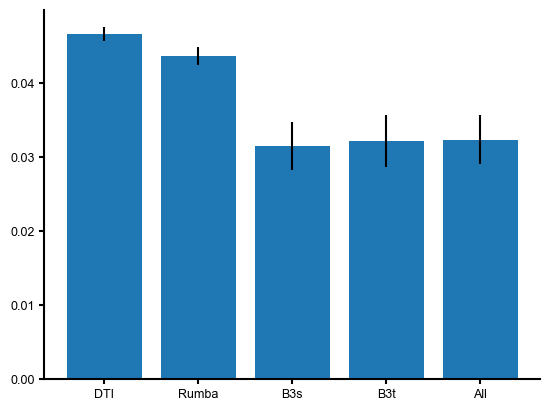

In [88]:
plt.bar(["DTI","Rumba", "B3s", "B3t", "All"], [dti_mean, rumba_mean, b3s_mean, b3t_mean, all_mean], yerr=[dti_std, rumba_std, b3s_std, b3t_std, all_std])
#plt.yscale('log')

In [89]:
from functools import partial

In [90]:
generalization_errors_b3s = 0
for i in range(5):
    keys = jax.random.split(jax.random.PRNGKey(i), full_data_flat_in_brain.shape[0])
    generalization_errors_b3s += jax.vmap(partial(pred_error, eval_index=5 + 20*i), in_axes=(0, None, None, 0))(keys, acq, m_b3s, full_data_flat_in_brain)
generalization_errors_b3s /= 5

In [91]:
generalization_errors_b3t = 0
for i in range(5):
    keys = jax.random.split(jax.random.PRNGKey(i), full_data_flat_in_brain.shape[0])
    generalization_errors_b3t += jax.vmap(partial(pred_error, eval_index=10 + 20*i), in_axes=(0, None, None, 0))(keys, acq, m_b3t, full_data_flat_in_brain)
generalization_errors_b3t /= 5

In [92]:
generalization_errors_all = 0
for i in range(5):
    keys = jax.random.split(jax.random.PRNGKey(i), full_data_flat_in_brain.shape[0])
    generalization_errors_all += jax.vmap(partial(pred_error, eval_index=100 + 20*i), in_axes=(0, None, None, 0))(keys, acq, None, full_data_flat_in_brain)
generalization_errors_all /= 5

In [93]:
generalization_errors_all

Array([5.3370699e-05, 9.7991338e-05, 3.8620838e-05, ..., 1.7645876e-05,
       1.3262753e-05, 7.7045726e-05], dtype=float32)

In [114]:
generalization_rmse_maps = 0
response, _ = auto_response_ssst(gtab, data_norm, roi_radii=10, fa_thr=0.7)
for i in range(2):
    eval_index = 5 + 20*i
    print(f"Evaluating generalization error at index {eval_index}")
    gtab_train = gradient_table(jnp.concat([bvals[:eval_index], bvals[eval_index+1:]]), jnp.concatenate([bvecs[:eval_index], bvecs[eval_index+1:]]))
    gtab_eval = gradient_table(jnp.array([bvals[eval_index]]), jnp.array([bvecs[eval_index]]))
    data_train = jnp.concatenate([full_data_flat_in_brain[:, :eval_index], full_data_flat_in_brain[:, eval_index+1:]], axis=1)
    data_eval = full_data_flat_in_brain[:, eval_index:eval_index+1]
    rumba = RumbaSDModel(gtab_train, voxelwise=True, wm_response=response[0])   # configure as needed
    fit = rumba.fit(data_train)                        # or rumba.fit(data, mask=mask) depending on DIPY version

    pred = fit.predict(gtab=gtab_eval)                # (X, Y, Z, N)
    resid = data_eval - pred                          # (X, Y, Z, N)
    # RMSE per voxel (scalar map):
    generalization_rmse_map += np.mean(resid**2, axis=-1)
generalization_rmse_map /= 2

Evaluating generalization error at index 5


/tmp/ipykernel_424769/1291706944.py:6: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  gtab_train = gradient_table(jnp.concat([bvals[:eval_index], bvals[eval_index+1:]]), jnp.concatenate([bvecs[:eval_index], bvecs[eval_index+1:]]))
/tmp/ipykernel_424769/1291706944.py:7: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  gtab_eval = gradient_table(jnp.array([bvals[eval_index]]), jnp.array([bvecs[eval_index]]))


Evaluating generalization error at index 25


In [ ]:
# DTI

generalization_rmse_tens = 0
for i in range(5):
    eval_index = 5 + 20*i
    print(f"Evaluating generalization error at index {eval_index}")
    gtab_train = gradient_table(jnp.concat([bvals[:eval_index], bvals[eval_index+1:]]), jnp.concatenate([bvecs[:eval_index], bvecs[eval_index+1:]]))
    gtab_eval = gradient_table(jnp.array([bvals[eval_index]]), jnp.array([bvecs[eval_index]]))
    data_train = jnp.concatenate([full_data_flat_in_brain[:, :eval_index], full_data_flat_in_brain[:, eval_index+1:]], axis=1)
    data_eval = full_data_flat_in_brain[:, eval_index:eval_index+1]
    ft = TensorModel(gtab_train).fit(data_train)
    pred_tens = ft.predict(gtab_eval)
    resid_tens = data_eval - pred_tens
    generalization_rmse_tens += np.mean(resid_tens**2, axis=-1)
generalization_rmse_tens /= 5

Evaluating generalization error at index 5
Evaluating generalization error at index 25


/tmp/ipykernel_424769/1372245523.py:7: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  gtab_train = gradient_table(jnp.concat([bvals[:eval_index], bvals[eval_index+1:]]), jnp.concatenate([bvecs[:eval_index], bvecs[eval_index+1:]]))
/tmp/ipykernel_424769/1372245523.py:8: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  gtab_eval = gradient_table(jnp.array([bvals[eval_index]]), jnp.array([bvecs[eval_index]]))


Evaluating generalization error at index 45


In [100]:
generalization_errors_b3s = generalization_errors_b3s[~jnp.isnan(generalization_errors_b3s)]
generalization_errors_b3t = generalization_errors_b3t[~jnp.isnan(generalization_errors_b3t)]
generalization_errors_all = generalization_errors_all[~jnp.isnan(generalization_errors_all)]

In [115]:
gen_b3s_mean, gen_b3s_std = bootstrap_mean(generalization_errors_b3s)
gen_b3t_mean, gen_b3t_std = bootstrap_mean(generalization_errors_b3t)
gen_all_mean, gen_all_std = bootstrap_mean(generalization_errors_all)
gen_rumba_mean, gen_rumba_std = bootstrap_mean(generalization_rmse_map)

In [108]:
gen_b3s_mean

Array(0.0324735, dtype=float32)

In [97]:
gen_dti_mean, gen_dti_std = bootstrap_mean(generalization_rmse_tens)

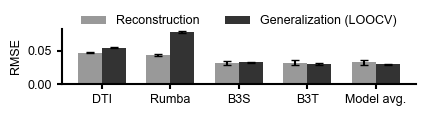

In [133]:
# Create a single plot with both training and generalization errors
fig, ax = plt.subplots(1, 1, figsize=(4.4, 1.5))

x = np.arange(5)
width = 0.35

# Training errors
train_bars = ax.bar(x - width/2, [dti_mean, rumba_mean, b3s_mean, b3t_mean, all_mean],
                   width, label='Reconstruction', yerr=[dti_std, rumba_std, b3s_std, b3t_std, all_std],
                   color='grey', alpha=0.8, capsize=3)

# Generalization errors
gen_bars = ax.bar(x + width/2, [gen_dti_mean, gen_rumba_mean, gen_b3s_mean, gen_b3t_mean, gen_all_mean],
                 width, label='Generalization (LOOCV)', yerr=[gen_dti_std, gen_rumba_std, gen_b3s_std, gen_b3t_std, gen_all_std],
                 color='k', alpha=0.8, capsize=3)

ax.set_ylabel('RMSE')
ax.set_xticks(x)
ax.set_xticklabels(["DTI", "Rumba", "B3S", "B3T", "Model avg."])
ax.legend(frameon=False, ncol=2, bbox_to_anchor=(0.5, 1.45), loc='upper center')
#ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.show()
fig.savefig("generalization_error.svg", dpi=300, bbox_inches='tight', transparent=True)


In [1]:
from functools import partial
generalization_errors_per_lam = {}
for lam in [0.0,0.5,0.90,0.95,1.0]:
    keys = jax.random.split(jax.random.PRNGKey(0), full_data_flat_in_brain.shape[0])
    generalization_errors_all = jax.vmap(partial(leave_one_out_error_jit, lam=lam), in_axes=(0, None, None, 0))(keys[:1000], acq, None, full_data_flat_in_brain[:1000])
    mean = jnp.nanmean(generalization_errors_all)
    std = jnp.nanstd(generalization_errors_all)
    generalization_errors_per_lam[lam] = (mean, std)

NameError: name 'jax' is not defined

In [2]:
generalization_errors_per_lam

{}

<ErrorbarContainer object of 3 artists>

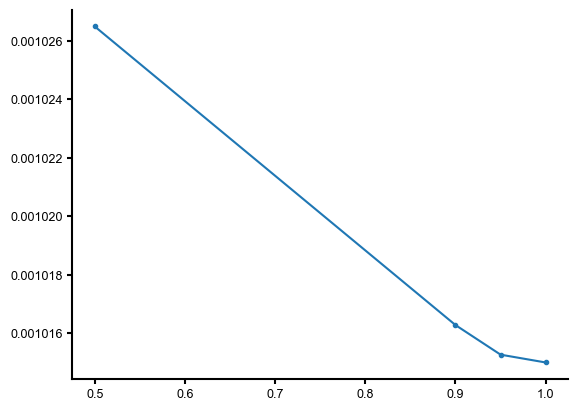

In [32]:
lams = list(generalization_errors_per_lam.keys())
means = [generalization_errors_per_lam[lam][0] for lam in lams]
stds = [generalization_errors_per_lam[lam][1] for lam in lams]
plt.errorbar(lams, means,  marker='o')